In [10]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import cv2
import os
import random

In [4]:
# bemeneti "kep" a kernel tesztelesehez
input_image = np.array([[1, 0, 0, 0, 1],
                        [0, 0, 0, 0, 0],
                        [1, 0, 0, 0, 1],
                        [0, 0, 0, 0, 0],
                        [1, 0, 0, 0, 1]], dtype=np.float32)

kernel = np.array([[1, 0, 0],
                   [1, 0, 0],
                   [1, 0, 0]], dtype=np.float32)

input_image_height, input_image_width = input_image.shape
kernel_height, kernel_width = kernel.shape

padding = 0
stride = 1

out_height = int((input_image_height - kernel_height + 2 * padding) / stride) + 1
out_width = int((input_image_width - kernel_width + 2 * padding) / stride) + 1
out_image = np.zeros((out_height, out_width))

for h in range(out_height):
    for w in range(out_width):
        out_image[h, w] = np.sum(input_image[h:h+kernel_height, w:w+kernel_width] * kernel)

# checking
print(out_image)

[[2. 0. 0.]
 [1. 0. 0.]
 [2. 0. 0.]]


In [5]:
class ConvolutionLayer:
    def __init__(self, kernel_num, kernel_size):
        self.kernel_num = kernel_num
        self.kernel_size = kernel_size
        self.kernels = np.random.randn(kernel_num, kernel_size, kernel_size) / (kernel_size**2)

    def patches_generator(self, image):
        image_h, image_w = image.shape
        patches = []
        for h in range(image_h - self.kernel_size + 1):
            for w in range(image_w - self.kernel_size + 1):
                patch = image[h:h+self.kernel_size, w:w+self.kernel_size]
                patches.append((patch, h, w))
        return patches
    
    def forward(self, image):
        image_h, image_w = image.shape
        convolution_output = np.zeros((image_h-self.kernel_size+1, image_w-self.kernel_size+1, self.kernel_num))
        for patch, h, w in self.patches_generator(image):
            convolution_output[h,w] = np.sum(patch * self.kernels, axis=(1,2))
        return convolution_output, self.kernels

In [6]:
def plot_convolution_output(convolution_output, kernels, title=None):
    nrows, ncols = 2, (convolution_output.shape[-1] + 1) // 2

    fig, axes = plt.subplots(nrows=nrows, ncols=ncols*2, figsize=(15, 6))

    for i in range(nrows):
        for j in range(ncols):
            idx = i * ncols + j
            if idx < convolution_output.shape[-1]:
                # Plot the kernel
                axes[i, j * 2].imshow(kernels[idx], cmap='viridis')
                axes[i, j * 2].set_xticks([])
                axes[i, j * 2].set_yticks([])
                axes[i, j * 2].set_title(f'Kernel {idx + 1}')

                # Plot the corresponding convolution output
                axes[i, j * 2 + 1].imshow(convolution_output[:, :, idx], cmap='viridis')
                axes[i, j * 2 + 1].set_xticks([])
                axes[i, j * 2 + 1].set_yticks([])
                axes[i, j * 2 + 1].set_title(f'Conv Output {idx + 1}')
            else:
                axes[i, j * 2].axis('off')
                axes[i, j * 2 + 1].axis('off')

    if title:
        fig.suptitle(title)

    plt.show()

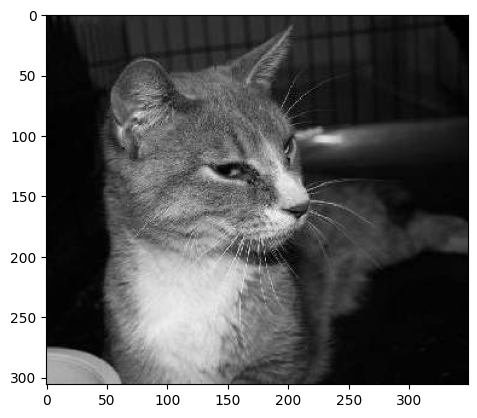

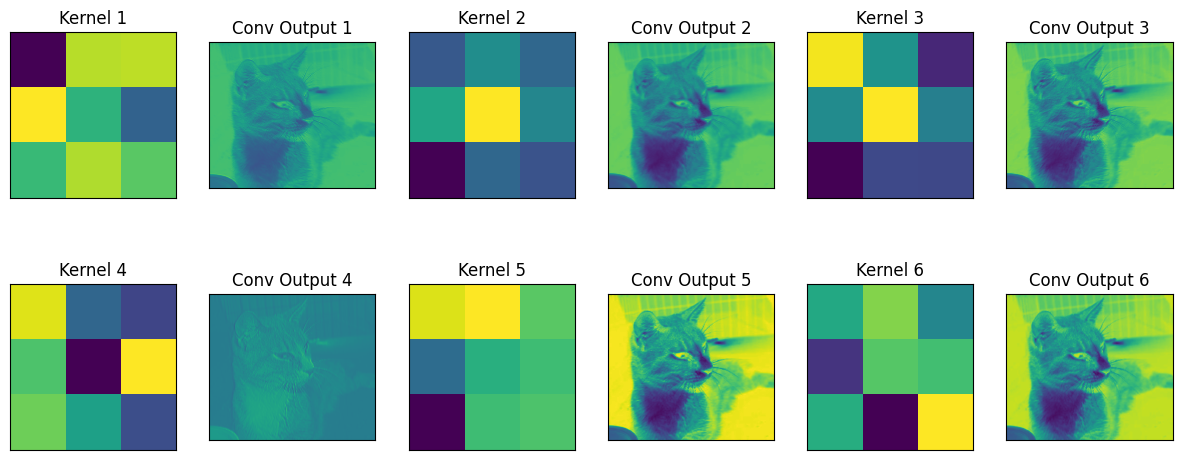

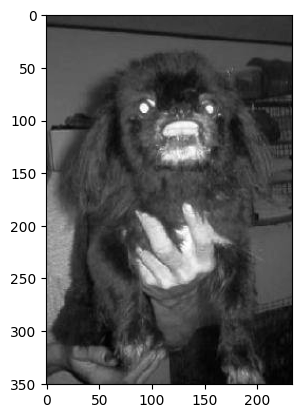

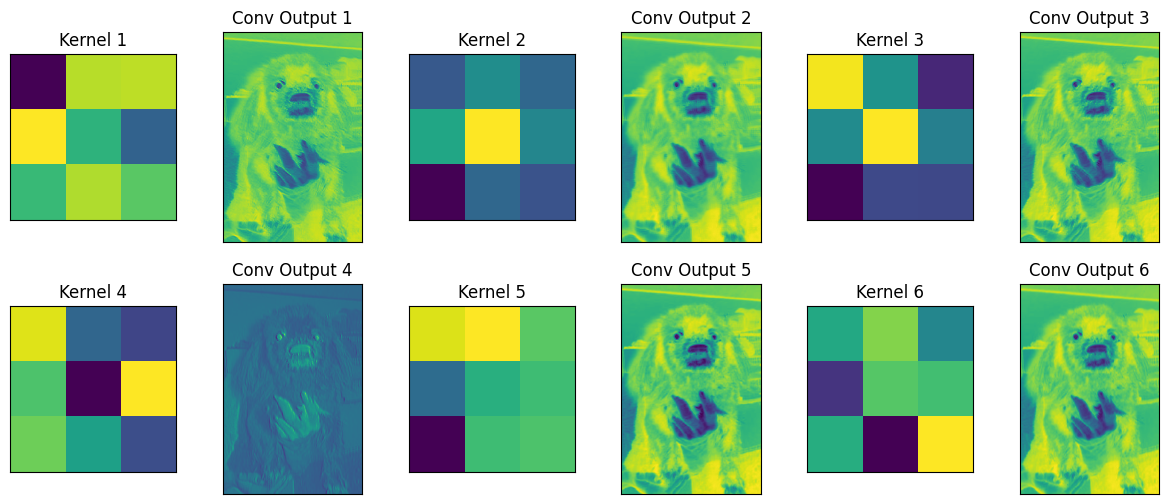

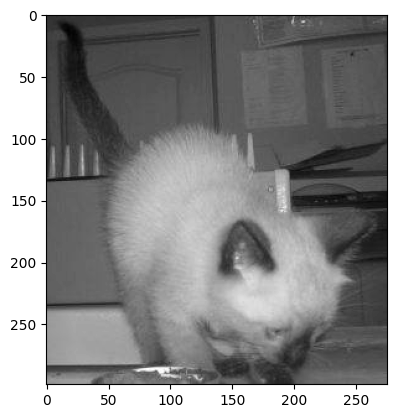

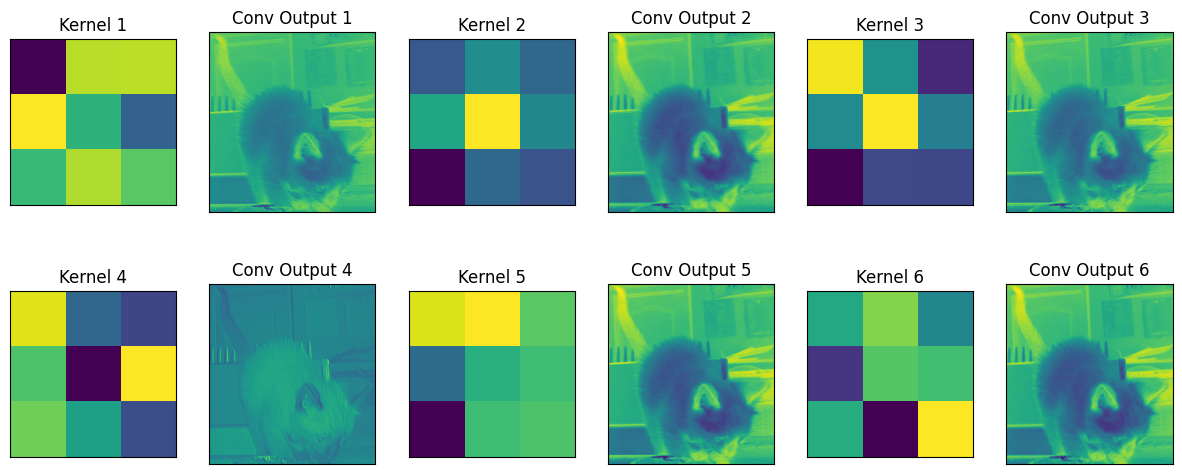

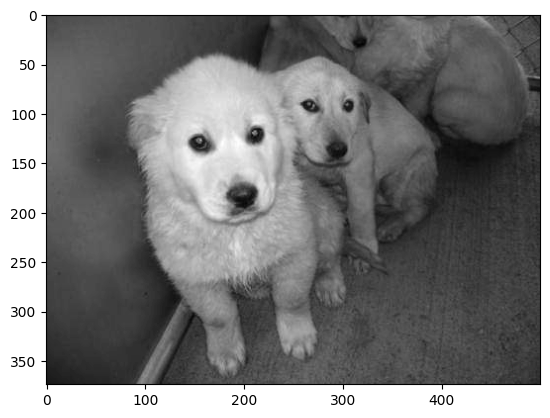

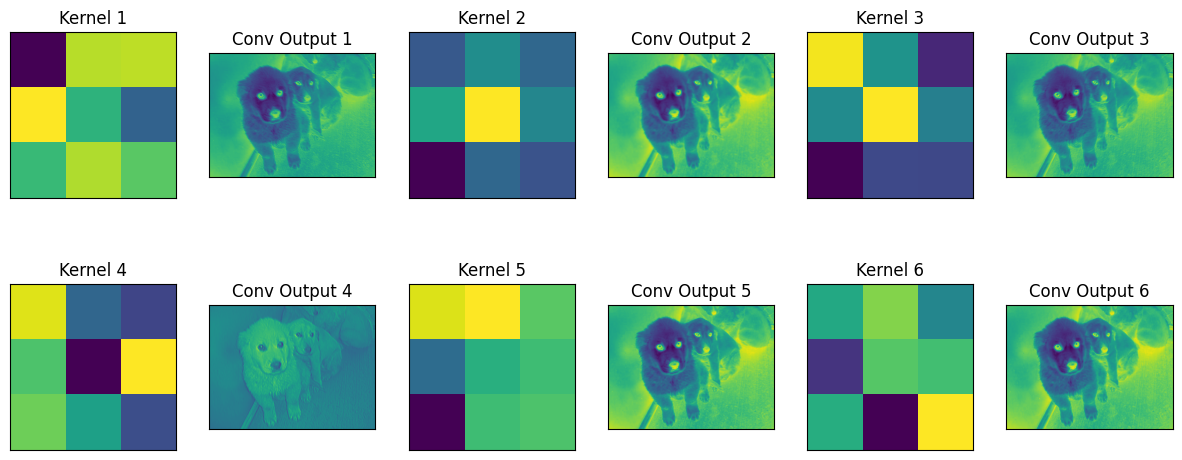

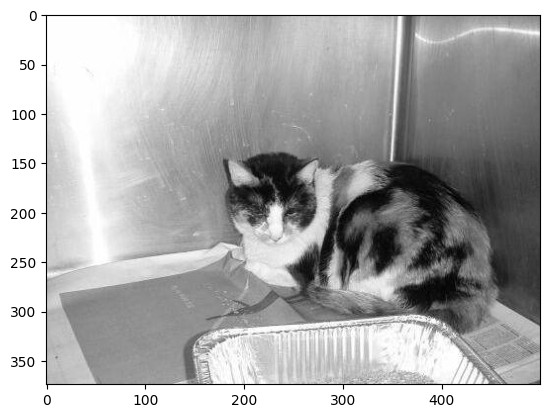

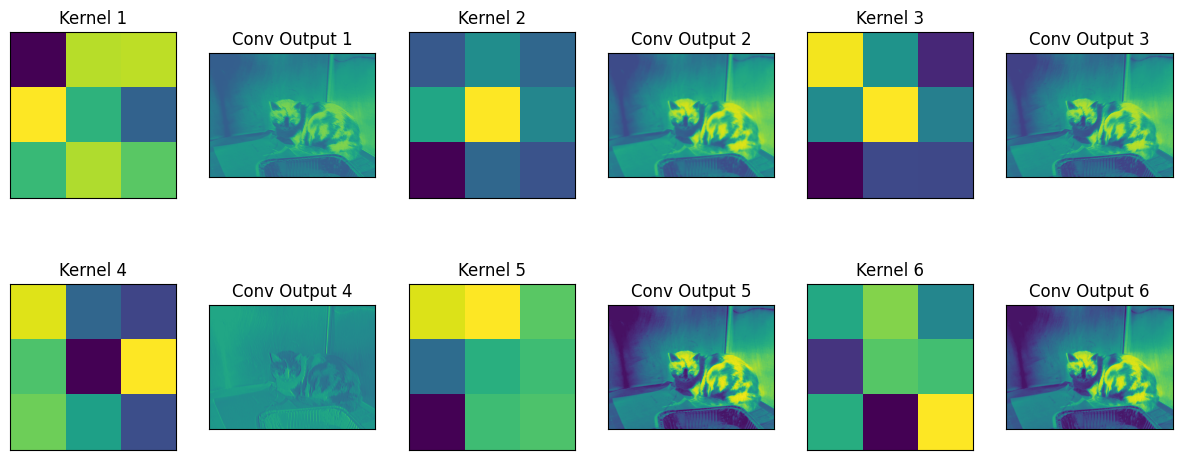

In [11]:
image_folder = "./train"
image_files = [os.path.join(image_folder, file) for file in os.listdir(image_folder) if file.endswith(('.jpg', '.png', '.jpeg'))]
n = 5
selected_files = random.sample(image_files, n)
images = [cv2.imread(file, cv2.IMREAD_GRAYSCALE) for file in selected_files]

kernel_num = 6
kernel_size = 3

conv = ConvolutionLayer(kernel_num=kernel_num,kernel_size=kernel_size)

for index in range(n):
    plt.imshow(images[index], cmap='gray')
    features,kernels = conv.forward(images[index])
    plot_convolution_output(features,kernels)